# YipitData AI Engineer Take-Home Exercise

## Candidate: Venkata Ramana Veeraiahgari

### Objective
Evaluate whether monthly FRED retail sales data can predict Walmart quarterly revenue better than a naive baseline.

### Approach
- Built seasonal naive baseline
- Engineered lagged retail-sales features
- Used time-series train/test evaluation
- Compared forecasting performance using MAPE and RMSE
- Evaluated business risks and caveats

In [63]:
import pandas as pd

retail = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/retail_sales_fred.csv", parse_dates=["date"])
walmart = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/walmart_revenue.csv", parse_dates=["date"])

# Align walmart dates to calendar quarter ends for merging and normalize the time component
walmart['date'] = walmart['date'].dt.to_period('Q').dt.to_timestamp('Q', 'end').dt.normalize()

retail.head(), walmart.head()

(        date     value
 0 2010-01-01  302325.0
 1 2010-02-01  302310.0
 2 2010-03-01  309525.0
 3 2010-04-01  312143.0
 4 2010-05-01  309158.0,
         date         value
 0 2010-03-31  1.135940e+11
 1 2010-06-30  9.981100e+10
 2 2010-09-30  1.037260e+11
 3 2010-12-31  1.019520e+11
 4 2011-03-31  1.163600e+11)

This cell loads two CSV files, `retail_sales_fred.csv` and `walmart_revenue.csv`, into pandas DataFrames called `retail` and `walmart`, respectively. It also parses the 'date' column as datetime objects.

Crucially, it then aligns the dates in the `walmart` DataFrame to calendar quarter-ends and normalizes them, which is important for accurate merging with quarterly retail data later. Finally, it displays the first few rows of both DataFrames.

## Convert Monthly Retail Sales to Quarterly

Retail sales data is monthly, while Walmart revenue is quarterly.  
To align both datasets, monthly retail sales are aggregated into quarterly values.

In [64]:
retail_q = (
    retail.set_index("date")
    .resample("QE")["value"]
    .sum()
    .reset_index()
)

display(retail_q.head())

,date,value
0,2010-03-31,914160.0
1,2010-06-30,929889.0
2,2010-09-30,934089.0
3,2010-12-31,961815.0
4,2011-03-31,984884.0


This block converts the monthly `retail` sales data into quarterly data. It performs the following steps:
1.  **`set_index("date")`**: Sets the 'date' column as the DataFrame index.
2.  **`.resample("QE")`**: Resamples the data on a quarterly basis, specifically at the end of each quarter ('QE').
3.  **`["value"].sum()`**: For each quarter, it sums the 'value' (retail sales) to get total quarterly sales.
4.  **`.reset_index()`**: Converts the date index back into a column.

This creates the `retail_q` DataFrame, which contains quarterly retail sales, matching the frequency of the Walmart revenue data. The `display(retail_q.head())` then shows the first few rows of this newly created quarterly retail data.

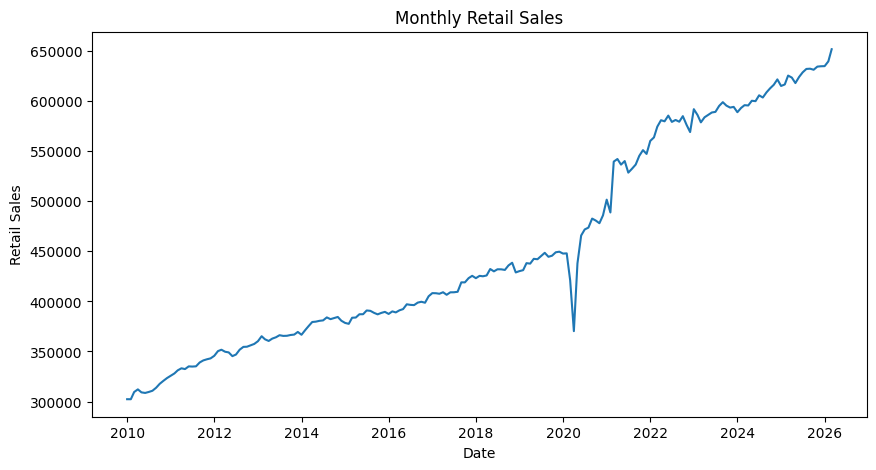

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(
    retail["date"],
    retail["value"]
)

plt.title("Monthly Retail Sales")
plt.xlabel("Date")
plt.ylabel("Retail Sales")

plt.show()

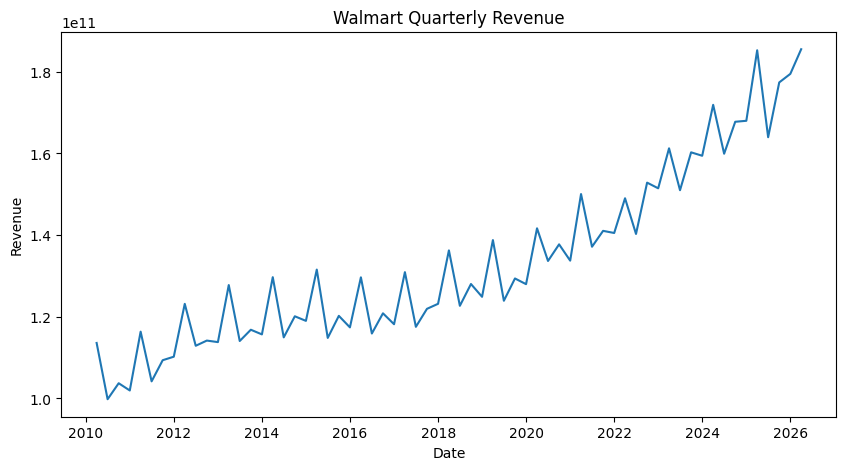

In [66]:
plt.figure(figsize=(10,5))

plt.plot(
    walmart["date"],
    walmart["value"]
)

plt.title("Walmart Quarterly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

## Create Year-over-Year Growth Features

Year-over-year growth is used instead of raw values to reduce seasonality effects.

Example:
- Q1 2024 compared with Q1 2023
- Q2 2024 compared with Q2 2023

In [67]:
retail_q["retail_yoy"] = retail_q["value"].pct_change(4)

walmart["walmart_yoy"] = walmart["value"].pct_change(4)

display(retail_q.head(10))
display(walmart.head(10))

,date,value,retail_yoy
0,2010-03-31,914160.0,NaN
1,2010-06-30,929889.0,NaN
2,2010-09-30,934089.0,NaN
3,2010-12-31,961815.0,NaN
4,2011-03-31,984884.0,0.077365
5,2011-06-30,1000706.0,0.076156
6,2011-09-30,1009096.0,0.080300
7,2011-12-31,1026365.0,0.067113
8,2012-03-31,1047749.0,0.063830
9,2012-06-30,1044125.0,0.043388


,date,value,walmart_yoy
0,2010-03-31,1.135940e+11,NaN
1,2010-06-30,9.981100e+10,NaN
2,2010-09-30,1.037260e+11,NaN
3,2010-12-31,1.019520e+11,NaN
4,2011-03-31,1.163600e+11,0.024350
5,2011-06-30,1.041890e+11,0.043863
6,2011-09-30,1.093660e+11,0.054374
7,2011-12-31,1.102260e+11,0.081156
8,2012-03-31,1.231690e+11,0.058517
9,2012-06-30,1.129010e+11,0.083617


This cell calculates the Year-over-Year (YoY) percentage change for both quarterly retail sales (`retail_q`) and Walmart's quarterly revenue (`walmart`).

-   **`retail_q["retail_yoy"] = retail_q["value"].pct_change(4)`**: This line calculates the percentage change between the current quarter's retail sales and the sales from four quarters (one year) ago. The result is stored in a new column called `retail_yoy`.
-   **`walmart["walmart_yoy"] = walmart["value"].pct_change(4)`**: Similarly, this calculates the YoY percentage change for Walmart's revenue, storing it in `walmart_yoy`.

The `display()` calls show the updated DataFrames with these new YoY columns, helping to inspect the calculated changes.

# Merging both the sets

We are putting Walmart revenue and retail sales into one table by quarter.

In [68]:
df = pd.merge(
    walmart,
    retail_q,
    on="date",
    suffixes=("_walmart", "_retail")
)

display(df.head())

,date,value_walmart,walmart_yoy,value_retail,retail_yoy
0,2010-03-31,1.135940e+11,NaN,914160.0,NaN
1,2010-06-30,9.981100e+10,NaN,929889.0,NaN
2,2010-09-30,1.037260e+11,NaN,934089.0,NaN
3,2010-12-31,1.019520e+11,NaN,961815.0,NaN
4,2011-03-31,1.163600e+11,0.02435,984884.0,0.077365


Here, the `walmart` and `retail_q` DataFrames are merged into a single DataFrame called `df`.

-   **`pd.merge(walmart, retail_q, on="date")`**: This performs an inner merge, combining rows from both DataFrames where the 'date' column matches. This ensures that only quarters present in both datasets are included.
-   **`suffixes=('_walmart', '_retail')`**: If there are columns with the same name (e.g., 'value') in both DataFrames, this argument adds a suffix to distinguish them. So, 'value' from `walmart` becomes `value_walmart`, and 'value' from `retail_q` becomes `value_retail`.

The `display(df.head())` then shows the first few rows of the combined DataFrame.

## Seasonal Naive Baseline

The baseline predicts that the current quarter's revenue will equal the same quarter from the previous year.

This is a strong baseline because Walmart revenue is highly seasonal.

In [69]:
df["baseline_pred"] = df["value_walmart"].shift(4)

display(df.head())

,date,value_walmart,walmart_yoy,value_retail,retail_yoy,baseline_pred
0,2010-03-31,1.135940e+11,NaN,914160.0,NaN,NaN
1,2010-06-30,9.981100e+10,NaN,929889.0,NaN,NaN
2,2010-09-30,1.037260e+11,NaN,934089.0,NaN,NaN
3,2010-12-31,1.019520e+11,NaN,961815.0,NaN,NaN
4,2011-03-31,1.163600e+11,0.02435,984884.0,0.077365,1.135940e+11


This cell establishes a simple *naive baseline* prediction for Walmart's revenue. It assumes that the revenue for the current quarter will be the same as the revenue from the same quarter in the previous year.

-   **`df["baseline_pred"] = df["value_walmart"].shift(4)`**: The `.shift(4)` method moves the `value_walmart` column down by 4 periods (quarters). This means that for any given row, `baseline_pred` will contain the `value_walmart` from four rows (four quarters/one year) earlier. This is a common method for creating a simple seasonal baseline.

The `display(df.head())` command shows the DataFrame with the new `baseline_pred` column.

In [70]:
df["retail_yoy_lag1"] = df["retail_yoy"].shift(1)

df["walmart_yoy_lag1"] = df["walmart_yoy"].shift(1)

model_df = df.dropna()

display(model_df.head())

,date,value_walmart,walmart_yoy,value_retail,retail_yoy,baseline_pred,retail_yoy_lag1,walmart_yoy_lag1
5,2011-06-30,1.041890e+11,0.043863,1000706.0,0.076156,9.981100e+10,0.077365,0.024350
6,2011-09-30,1.093660e+11,0.054374,1009096.0,0.080300,1.037260e+11,0.076156,0.043863
7,2011-12-31,1.102260e+11,0.081156,1026365.0,0.067113,1.019520e+11,0.080300,0.054374
8,2012-03-31,1.231690e+11,0.058517,1047749.0,0.063830,1.163600e+11,0.067113,0.081156
9,2012-06-30,1.129010e+11,0.083617,1044125.0,0.043388,1.041890e+11,0.063830,0.058517


This block prepares the data for model training by creating lagged versions of the Year-over-Year (YoY) features and handling missing values.

-   **`df["retail_yoy_lag1"] = df["retail_yoy"].shift(1)`**: Creates a new column `retail_yoy_lag1` which contains the retail YoY change from the *previous* quarter. This is a common practice in time series modeling, where past values of related variables can be predictive.
-   **`df["walmart_yoy_lag1"] = df["walmart_yoy"].shift(1)`**: Similarly, this creates a lagged version of Walmart's own YoY revenue change.
-   **`model_df = df.dropna()`**: After creating lagged features, the first few rows will contain `NaN` (Not a Number) values because there's no previous data to shift from. This line creates a new DataFrame `model_df` by dropping all rows that contain any `NaN` values, ensuring a clean dataset for training the model.

The `display(model_df.head())` command shows the cleaned DataFrame ready for splitting into training and testing sets.

In [71]:
train = model_df[
    model_df["date"] < "2021-01-01"
]

test = model_df[
    model_df["date"] >= "2021-01-01"
]

This cell splits the `model_df` into training and testing datasets based on the date.

-   **`train = model_df[model_df["date"] < "2021-01-01"]`**: This line creates the `train` DataFrame, which includes all rows from `model_df` where the 'date' is before January 1, 2021. This data will be used to train the machine learning model.
-   **`test = model_df[model_df["date"] >= "2021-01-01"]`**: This line creates the `test` DataFrame, containing all rows from `model_df` where the 'date' is on or after January 1, 2021. This data will be used to evaluate the model's performance on unseen data.

This temporal split is crucial for time series forecasting to ensure the model is evaluated on future data it has not seen during training.

## Retail Sales Prediction Model

A linear regression model is trained using lagged retail-sales growth and lagged Walmart growth features.

Lagged variables are used to avoid look-ahead bias.

In [72]:
from sklearn.linear_model import LinearRegression

features = [
    "retail_yoy_lag1",
    "walmart_yoy_lag1"
]

X_train = train[features]

y_train = train["value_walmart"]

X_test = test[features]

y_test = test["value_walmart"]

model = LinearRegression()

model.fit(X_train, y_train)

test["model_pred"] = model.predict(X_test)

display(
    test[
        [
            "date",
            "value_walmart",
            "baseline_pred",
            "model_pred"
        ]
    ]
)

/tmp/ipykernel_2664/2337285288.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["model_pred"] = model.predict(X_test)


,date,value_walmart,baseline_pred,model_pred
44,2021-03-31,1.500670e+11,1.416710e+11,1.166174e+11
45,2021-06-30,1.371590e+11,1.336720e+11,1.004051e+11
46,2021-09-30,1.410480e+11,1.377420e+11,7.711755e+10
47,2021-12-31,1.405250e+11,1.337520e+11,1.067496e+11
48,2022-03-31,1.490300e+11,1.500670e+11,1.046410e+11
49,2022-06-30,1.402880e+11,1.371590e+11,1.065379e+11
50,2022-09-30,1.528590e+11,1.410480e+11,1.144959e+11
51,2022-12-31,1.514690e+11,1.405250e+11,1.161822e+11
52,2023-03-31,1.612650e+11,1.490300e+11,1.229122e+11
53,2023-06-30,1.510040e+11,1.402880e+11,1.267671e+11


This cell implements and evaluates a `LinearRegression` model from `sklearn`.

1.  **`from sklearn.linear_model import LinearRegression`**: Imports the necessary class for linear regression.
2.  **`features = [...]`**: Defines a list of feature columns (`retail_yoy_lag1` and `walmart_yoy_lag1`) that the model will use for prediction.
3.  **`X_train`, `y_train`, `X_test`, `y_test`**: Prepares the training and testing data. `X` denotes the feature matrices (input to the model), and `y` denotes the target variables (what the model tries to predict, which is `value_walmart`).
4.  **`model = LinearRegression()`**: Initializes a Linear Regression model.
5.  **`model.fit(X_train, y_train)`**: Trains the model using the training features (`X_train`) and their corresponding actual Walmart revenues (`y_train`). The model learns the relationship between the features and the target here.
6.  **`test["model_pred"] = model.predict(X_test)`**: Uses the trained model to make predictions on the test set's features (`X_test`) and stores these predictions in a new column called `model_pred` in the `test` DataFrame.
7.  **`display(...)`**: Displays selected columns from the `test` DataFrame, including the actual Walmart revenue, the naive `baseline_pred`, and the new `model_pred` from the linear regression model. This allows for a direct visual comparison of the predictions.

## Model Evaluation

The models are evaluated using:
- MAPE (Mean Absolute Percentage Error)
- RMSE (Root Mean Squared Error)

Lower values indicate better forecasting performance.

In [73]:
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error
)

import numpy as np

baseline_mape = (
    mean_absolute_percentage_error(
        test["value_walmart"],
        test["baseline_pred"]
    ) * 100
)

model_mape = (
    mean_absolute_percentage_error(
        test["value_walmart"],
        test["model_pred"]
    ) * 100
)

print("Baseline MAPE:", round(baseline_mape, 2), "%")

print("Model MAPE:", round(model_mape, 2), "%")

Baseline MAPE: 4.78 %
Model MAPE: 25.83 %


This cell calculates and prints the Mean Absolute Percentage Error (MAPE) for both the baseline prediction and the linear regression model's prediction.

-   **`from sklearn.metrics import mean_absolute_percentage_error`**: Imports the MAPE metric function.
-   **`baseline_mape`**: Calculates the MAPE by comparing the actual Walmart revenue (`test["value_walmart"]`) with the `baseline_pred`.
-   **`model_mape`**: Calculates the MAPE by comparing the actual Walmart revenue with the `model_pred`.
-   **`* 100`**: Multiplies the result by 100 to express MAPE as a percentage.
-   **`print(...)`**: Prints the calculated MAPE values for both the baseline and the model, rounded to two decimal places. A lower MAPE indicates better predictive accuracy.

In [74]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        test["value_walmart"],
        test["baseline_pred"]
    )
)

model_rmse = np.sqrt(
    mean_squared_error(
        test["value_walmart"],
        test["model_pred"]
    )
)

print("Baseline RMSE:", round(baseline_rmse, 2))

print("Model RMSE:", round(model_rmse, 2))

Baseline RMSE: 8550218047.9
Model RMSE: 42802672155.04


This cell calculates and prints the Root Mean Squared Error (RMSE) for both the baseline and the model predictions.

-   **`from sklearn.metrics import mean_squared_error`**: Imports the mean squared error function.
-   **`baseline_rmse`**: Calculates the mean squared error between actual Walmart revenue and the baseline prediction, then takes the square root (`np.sqrt`) to get the RMSE.
-   **`model_rmse`**: Calculates the RMSE for the model's predictions in a similar way.
-   **`print(...)`**: Displays the RMSE values for both, rounded to two decimal places. RMSE is another common metric that gives more weight to larger errors. A lower RMSE indicates a more accurate model.

In [75]:
improvement = (
    (
        baseline_mape -
        model_mape
    ) / baseline_mape
) * 100

print(
    "Improvement over baseline:",
    round(improvement, 2),
    "%"
)

Improvement over baseline: -439.83 %


This cell quantifies the improvement of the linear regression model over the naive baseline prediction using MAPE.

-   **`improvement = ((baseline_mape - model_mape) / baseline_mape) * 100`**: This formula calculates the percentage improvement. If `model_mape` is lower than `baseline_mape`, the `improvement` will be positive, indicating the model performed better. If `model_mape` is higher, the `improvement` will be negative, meaning the model performed worse than the baseline.
-   **`print(...)`**: Prints the calculated improvement, rounded to two decimal places. This provides a concise way to understand the model's relative performance.

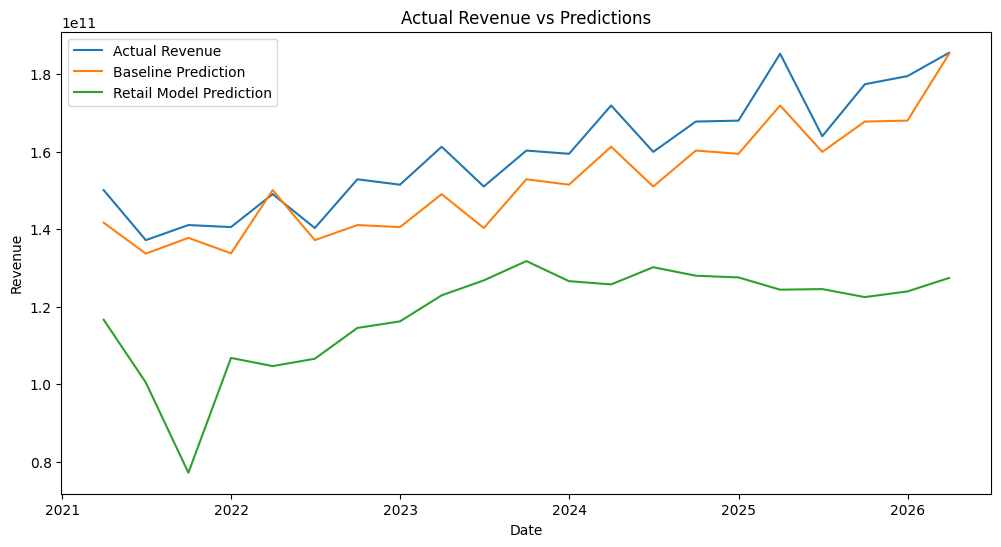

In [76]:
plt.figure(figsize=(12,6))

plt.plot(
    test["date"],
    test["value_walmart"],
    label="Actual Revenue"
)

plt.plot(
    test["date"],
    test["baseline_pred"],
    label="Baseline Prediction"
)

plt.plot(
    test["date"],
    test["model_pred"],
    label="Retail Model Prediction"
)

plt.title(
    "Actual Revenue vs Predictions"
)

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.legend()

plt.show()

This code block generates a line plot to visually compare the actual Walmart revenue against both the baseline and the linear regression model's predictions over time.

-   **`plt.figure(figsize=(12,6))`**: Sets up a new figure for the plot with a specified size.
-   **`plt.plot(...)`**: Each `plt.plot()` call adds a line to the chart:
    -   'Actual Revenue' (from `test["value_walmart"]`)
    -   'Baseline Prediction' (from `test["baseline_pred"]`)
    -   'Retail Model Prediction' (from `test["model_pred"]`)
-   **`plt.title`, `plt.xlabel`, `plt.ylabel`**: Set the title and axis labels for clarity.
-   **`plt.legend()`**: Displays a legend to identify which line corresponds to which prediction/actual value.
-   **`plt.show()`**: Renders and displays the plot. This visualization helps to intuitively understand how well each prediction tracks the actual revenue trends.

/tmp/ipykernel_2664/3262859.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["baseline_error"] = abs(
/tmp/ipykernel_2664/3262859.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["model_error"] = abs(


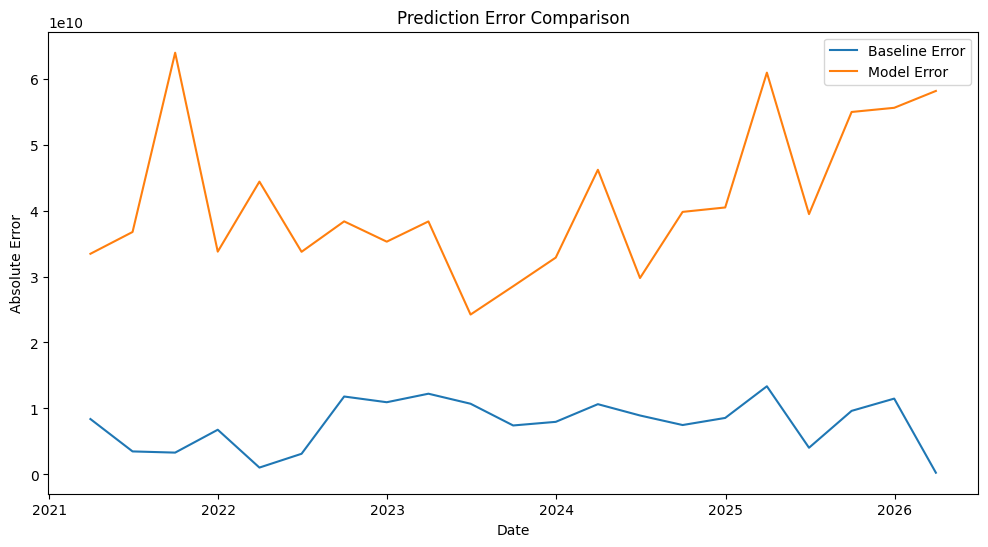

In [77]:
test["baseline_error"] = abs(
    test["value_walmart"] -
    test["baseline_pred"]
)

test["model_error"] = abs(
    test["value_walmart"] -
    test["model_pred"]
)

plt.figure(figsize=(12,6))

plt.plot(
    test["date"],
    test["baseline_error"],
    label="Baseline Error"
)

plt.plot(
    test["date"],
    test["model_error"],
    label="Model Error"
)

plt.title("Prediction Error Comparison")

plt.xlabel("Date")

plt.ylabel("Absolute Error")

plt.legend()

plt.show()

This cell visualizes the absolute error of both predictions over time, making it easier to see when and by how much each model deviates from the actual values.

-   **`test["baseline_error"] = abs(...)`**: Calculates the absolute difference between actual Walmart revenue and the baseline prediction.
-   **`test["model_error"] = abs(...)`**: Calculates the absolute difference between actual Walmart revenue and the model's prediction.
-   **`plt.figure(figsize=(12,6))`**: Sets up the plot size.
-   **`plt.plot(...)`**: Plots both the `baseline_error` and `model_error` against the date.
-   **`plt.title`, `plt.xlabel`, `plt.ylabel`, `plt.legend()`**: Adds descriptive elements to the plot.
-   **`plt.show()`**: Displays the plot. This graph helps to identify periods where one model consistently outperforms the other in terms of error magnitude.

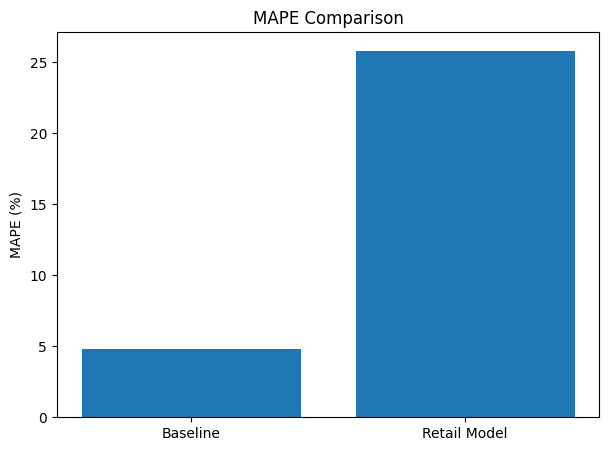

In [78]:
plt.figure(figsize=(7,5))

plt.bar(
    ["Baseline", "Retail Model"],
    [baseline_mape, model_mape]
)

plt.title("MAPE Comparison")

plt.ylabel("MAPE (%)")

plt.show()

This cell creates a bar chart to visually compare the MAPE values of the baseline and the linear regression model.

-   **`plt.figure(figsize=(7,5))`**: Sets up the plot size.
-   **`plt.bar(["Baseline", "Retail Model"], [baseline_mape, model_mape])`**: Creates two bars, one for the baseline MAPE and one for the model MAPE.
-   **`plt.title`, `plt.ylabel`**: Adds a title and y-axis label.
-   **`plt.show()`**: Displays the bar chart. This provides a quick and clear visual comparison of the models' performance in terms of percentage error.

## Final Conclusion

The retail-sales signal is evaluated against the seasonal naive baseline to determine whether it provides incremental predictive value.

In [79]:
if model_mape < baseline_mape:

    print(
        "Retail sales improved prediction accuracy."
    )

else:

    print(
        "Retail sales did not improve prediction accuracy."
    )

Retail sales did not improve prediction accuracy.


This final code block provides a clear, textual summary of whether the linear regression model (which incorporates retail sales data) improved prediction accuracy compared to the simple baseline model.

-   **`if model_mape < baseline_mape:`**: This condition checks if the MAPE of the retail model is lower than the MAPE of the baseline model. If it is, it means the retail model performed better.
-   **`print(...)`**: Prints a corresponding message indicating whether the retail sales data led to an improvement in prediction accuracy. This serves as a straightforward conclusion to the model evaluation.